# Movie Acquisition Prioritization (Proxy-Based)

## Business framing
We are building a decision-support workflow for content acquisition.

- `imdbRating` is used as a proxy for expected satisfaction / perceived quality.
- `numberOfVotes` is used as a proxy for public attention / expected reach.
- The recommendation is constrained to one service language: **English** (`firstLanguage == "en"`).
- This notebook supports acquisition prioritization, not true ROI prediction.

## Objective
Recommend a balanced portfolio of **English-language** movies that combines:
1. expected quality
2. expected reach
3. catalog diversity (genres and countries)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


pd.set_option("display.max_columns", 100)

data_path = "/Users/andreas/Will-Agency-42576-From-analytics-to-action-/Data/European_data_2000.csv"
df = pd.read_csv(data_path)

print(f"Loaded rows: {len(df):,}")
print(f"Loaded columns: {df.shape[1]:,}")
print("Columns:")
print(df.columns.tolist())


Loaded rows: 2,000
Loaded columns: 23
Columns:
['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear', 'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes', 'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage', 'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort', 'plotMedium', 'plotLong', 'genres', 'keywords', 'production']


## Baseline scoring model (V1)

### Scope constraint
We rank only titles where `firstLanguage == "en"` (and non-adult).

### 1) Weighted quality score core
To avoid over-trusting movies with very few votes, use a weighted rating:

`WR_i = (v_i / (v_i + m)) * R_i + (m / (v_i + m)) * C`

- `R_i`: movie `imdbRating`
- `v_i`: movie `numberOfVotes`
- `C`: mean `imdbRating` in the English non-adult ranking set
- `m`: vote threshold (75th percentile of `numberOfVotes`)

### 2) Reach transformation
Use `log_votes = log1p(numberOfVotes)` because votes are typically right-skewed.
This reduces dominance from a few extremely popular titles.

### 3) Subscores and combined score
- `quality_score = percentile_rank(weighted_rating) * 100`
- `reach_score = percentile_rank(log_votes) * 100`
- `acquisition_score = 0.60 * quality_score + 0.40 * reach_score`


In [13]:
model_cols = [
    "titleId",
    "originalTitle",
    "releaseYear",
    "runtimeMinutes",
    "imdbRating",
    "numberOfVotes",
    "genres",
    "mainCountry",
    "firstLanguage",
    "isAdult",
]

work = df[model_cols].copy()

work["imdbRating"] = pd.to_numeric(work["imdbRating"], errors="coerce")
work["numberOfVotes"] = pd.to_numeric(work["numberOfVotes"], errors="coerce")
work["firstLanguage_norm"] = work["firstLanguage"].astype(str).str.strip().str.lower()
work["isAdult_flag"] = work["isAdult"].isin([True, 1, "1", "True", "true"])

service_language = "en"

rank_df = work.loc[
    (~work["isAdult_flag"]) & (work["firstLanguage_norm"] == service_language)
].dropna(subset=["imdbRating", "numberOfVotes"]).copy()

C = rank_df["imdbRating"].mean()
m = rank_df["numberOfVotes"].quantile(0.75)

rank_df["weighted_rating"] = (
    (rank_df["numberOfVotes"] / (rank_df["numberOfVotes"] + m)) * rank_df["imdbRating"]
    + (m / (rank_df["numberOfVotes"] + m)) * C
)

rank_df["log_votes"] = np.log1p(rank_df["numberOfVotes"])

rank_df["quality_score"] = rank_df["weighted_rating"].rank(pct=True) * 100
rank_df["reach_score"] = rank_df["log_votes"].rank(pct=True) * 100
rank_df["acquisition_score"] = 0.60 * rank_df["quality_score"] + 0.40 * rank_df["reach_score"]

rank_df["score_norm"] = (
    (rank_df["acquisition_score"] - rank_df["acquisition_score"].min())
    / (rank_df["acquisition_score"].max() - rank_df["acquisition_score"].min() + 1e-9)
)

print(f"Service language filter: {service_language}")
print(f"Original rows: {len(work):,}")
print(f"Ranking universe (English + non-adult): {len(rank_df):,}")
print(f"Excluded adult titles: {int(work['isAdult_flag'].sum()):,}")
print(f"Global mean rating C (English set): {C:.3f}")
print(f"Vote threshold m (75th percentile, English set): {m:.1f}")

v1_cols = [
    "titleId",
    "originalTitle",
    "imdbRating",
    "numberOfVotes",
    "weighted_rating",
    "quality_score",
    "reach_score",
    "acquisition_score",
    "genres",
    "mainCountry",
    "firstLanguage",
]

top20_pure = rank_df.sort_values("acquisition_score", ascending=False).head(20).copy()
display(top20_pure[v1_cols].round(3))


Service language filter: en
Original rows: 2,000
Ranking universe (English + non-adult): 1,424
Excluded adult titles: 3
Global mean rating C (English set): 6.289
Vote threshold m (75th percentile, English set): 63532.0


,titleId,originalTitle,imdbRating,numberOfVotes,weighted_rating,quality_score,reach_score,acquisition_score,genres,mainCountry,firstLanguage
1452,tt0137523,Fight Club,8.8,2407126.0,8.735,100.000,100.000,100.000,Drama,DE,en
956,tt0110413,Léon,8.5,1280541.0,8.395,99.930,99.930,99.930,"Action, Crime, Drama, Thriller",FR,en
1806,tt0081505,The Shining,8.4,1144494.0,8.289,99.789,99.860,99.817,"Drama, Horror",GB,en
1065,tt0253474,The Pianist,8.5,945171.0,8.361,99.860,99.719,99.803,"Biography, Drama, Music, War",FR,en
1198,tt0066921,A Clockwork Orange,8.2,899582.0,8.074,99.649,99.649,99.649,"Crime, Sci-Fi",GB,en
1383,tt1201607,Harry Potter and the Deathly Hallows - Part 2,8.1,976358.0,7.989,99.438,99.789,99.579,"Adventure, Family, Fantasy, Mystery",GB,en
309,tt0062622,2001: A Space Odyssey,8.3,740608.0,8.141,99.719,99.017,99.438,"Adventure, Sci-Fi",GB,en
249,tt1205489,Gran Torino,8.1,829091.0,7.971,99.368,99.508,99.424,Drama,DE,en
539,tt2024544,12 Years a Slave,8.1,754989.0,7.959,99.228,99.368,99.284,"Biography, Drama, History",GB,en
1267,tt8579674,1917,8.2,707375.0,8.043,99.579,98.666,99.213,"Action, Drama, War",GB,en


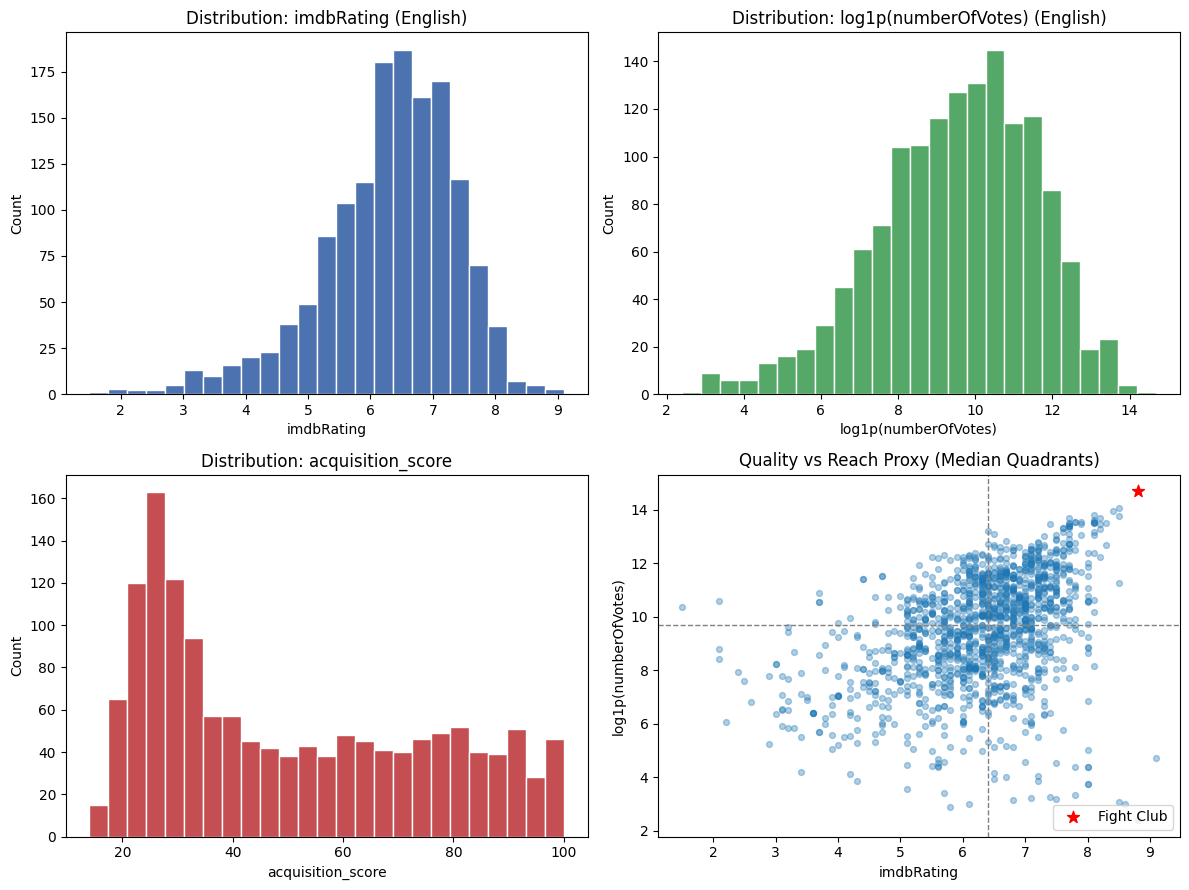

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(rank_df["imdbRating"], bins=25, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Distribution: imdbRating (English)")
axes[0, 0].set_xlabel("imdbRating")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(rank_df["log_votes"], bins=25, color="#55A868", edgecolor="white")
axes[0, 1].set_title("Distribution: log1p(numberOfVotes) (English)")
axes[0, 1].set_xlabel("log1p(numberOfVotes)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(rank_df["acquisition_score"], bins=25, color="#C44E52", edgecolor="white")
axes[1, 0].set_title("Distribution: acquisition_score")
axes[1, 0].set_xlabel("acquisition_score")
axes[1, 0].set_ylabel("Count")

axes[1, 1].scatter(rank_df["imdbRating"], rank_df["log_votes"], alpha=0.35, s=18)
axes[1, 1].axvline(rank_df["imdbRating"].median(), linestyle="--", color="gray", linewidth=1)
axes[1, 1].axhline(rank_df["log_votes"].median(), linestyle="--", color="gray", linewidth=1)
axes[1, 1].set_title("Quality vs Reach Proxy (Median Quadrants)")
axes[1, 1].set_xlabel("imdbRating")
axes[1, 1].set_ylabel("log1p(numberOfVotes)")

fight_mask = rank_df["originalTitle"].str.contains("fight club", case=False, na=False)
if fight_mask.any():
    fight_point = rank_df.loc[fight_mask].sort_values("numberOfVotes", ascending=False).iloc[0]
    axes[1, 1].scatter(
        fight_point["imdbRating"],
        fight_point["log_votes"],
        color="red",
        s=80,
        marker="*",
        label="Fight Club",
        zorder=5,
    )
    axes[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## Why does Fight Club rank highly? (diagnostic section)

This section explains the ranking using score decomposition and simple experiments.


,metric,value
0,rank_position,1.000000e+00
1,rank_percentile_top,1.000000e+02
2,imdbRating,8.800000e+00
3,numberOfVotes,2.407126e+06
4,weighted_rating,8.735428e+00
5,quality_score,1.000000e+02
6,reach_score,1.000000e+02
7,quality_contribution,6.000000e+01
8,reach_contribution,4.000000e+01
9,acquisition_score,1.000000e+02


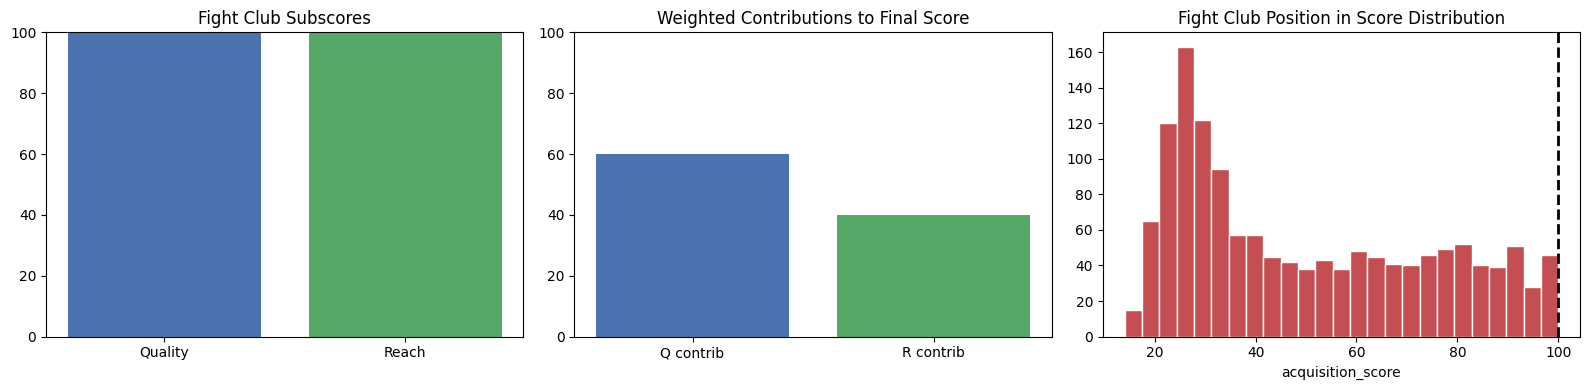

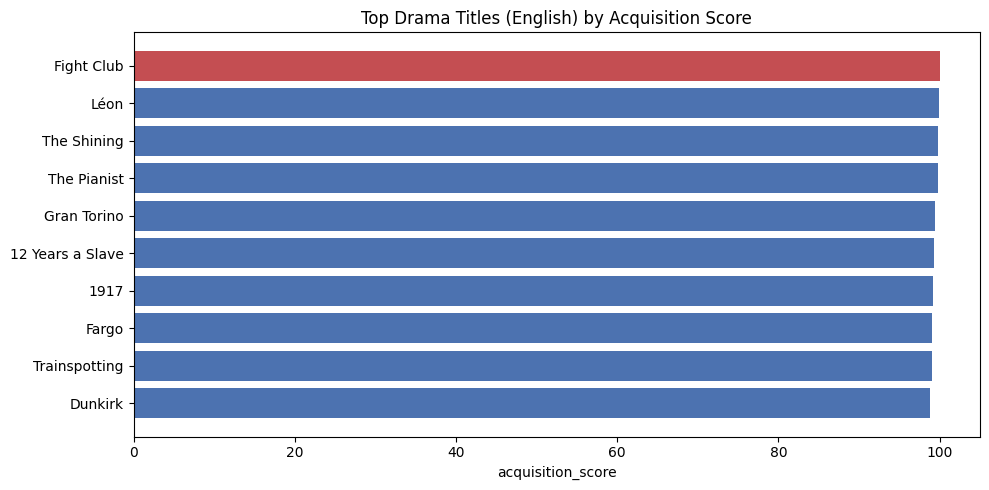

In [15]:
fight_candidates = rank_df[rank_df["originalTitle"].str.contains("fight club", case=False, na=False)].copy()

if len(fight_candidates) == 0:
    print("Fight Club not found in the English ranking universe.")
else:
    fight_row = fight_candidates.sort_values("numberOfVotes", ascending=False).iloc[0]

    ranked = rank_df.sort_values("acquisition_score", ascending=False).reset_index(drop=True)
    fight_rank = int(ranked.index[ranked["titleId"] == fight_row["titleId"]][0]) + 1
    fight_pct = 100 * (1 - (fight_rank - 1) / len(ranked))

    quality_contrib = 0.60 * fight_row["quality_score"]
    reach_contrib = 0.40 * fight_row["reach_score"]

    summary = pd.DataFrame(
        {
            "metric": [
                "rank_position",
                "rank_percentile_top",
                "imdbRating",
                "numberOfVotes",
                "weighted_rating",
                "quality_score",
                "reach_score",
                "quality_contribution",
                "reach_contribution",
                "acquisition_score",
            ],
            "value": [
                fight_rank,
                fight_pct,
                fight_row["imdbRating"],
                fight_row["numberOfVotes"],
                fight_row["weighted_rating"],
                fight_row["quality_score"],
                fight_row["reach_score"],
                quality_contrib,
                reach_contrib,
                fight_row["acquisition_score"],
            ],
        }
    )
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].bar(["Quality", "Reach"], [fight_row["quality_score"], fight_row["reach_score"]], color=["#4C72B0", "#55A868"])
    axes[0].set_title("Fight Club Subscores")
    axes[0].set_ylim(0, 100)

    axes[1].bar(["Q contrib", "R contrib"], [quality_contrib, reach_contrib], color=["#4C72B0", "#55A868"])
    axes[1].set_title("Weighted Contributions to Final Score")
    axes[1].set_ylim(0, 100)

    axes[2].hist(rank_df["acquisition_score"], bins=25, color="#C44E52", edgecolor="white")
    axes[2].axvline(fight_row["acquisition_score"], color="black", linestyle="--", linewidth=2)
    axes[2].set_title("Fight Club Position in Score Distribution")
    axes[2].set_xlabel("acquisition_score")

    plt.tight_layout()
    plt.show()

    peer_df = rank_df[rank_df["genres"].fillna("").str.contains("Drama", case=False, na=False)].copy()
    peer_top = peer_df.sort_values("acquisition_score", ascending=False).head(12)

    plt.figure(figsize=(10, 5))
    plt.barh(peer_top["originalTitle"], peer_top["acquisition_score"], color="#4C72B0")
    if fight_row["titleId"] in peer_top["titleId"].values:
        y_labels = list(peer_top["originalTitle"])
        y_idx = y_labels.index(fight_row["originalTitle"])
        plt.barh(peer_top.iloc[y_idx]["originalTitle"], peer_top.iloc[y_idx]["acquisition_score"], color="#C44E52")
    plt.gca().invert_yaxis()
    plt.xlabel("acquisition_score")
    plt.title("Top Drama Titles (English) by Acquisition Score")
    plt.tight_layout()
    plt.show()


## Experiment: How sensitive is Fight Club rank to score weights?

We vary quality weight from 0.30 to 0.90 (`reach weight = 1 - quality weight`).


,w_quality,w_reach,fight_rank
0,0.30,0.70,1
1,0.35,0.65,1
2,0.40,0.60,1
3,0.45,0.55,1
4,0.50,0.50,1
5,0.55,0.45,1
6,0.60,0.40,1
7,0.65,0.35,1
8,0.70,0.30,1
9,0.75,0.25,1


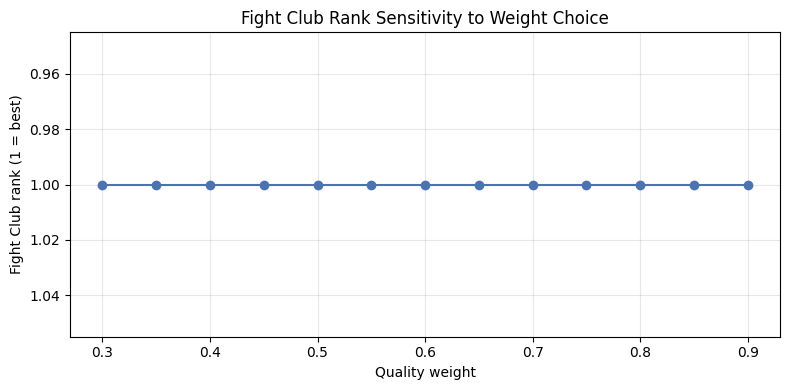

In [16]:
fight_candidates = rank_df[rank_df["originalTitle"].str.contains("fight club", case=False, na=False)].copy()

if len(fight_candidates) == 0:
    print("Fight Club not found in the English ranking universe.")
else:
    fight_id = fight_candidates.sort_values("numberOfVotes", ascending=False).iloc[0]["titleId"]

    rows = []
    for wq in np.round(np.linspace(0.30, 0.90, 13), 2):
        wr = 1.0 - wq
        tmp = rank_df[["titleId", "quality_score", "reach_score"]].copy()
        tmp["score_temp"] = wq * tmp["quality_score"] + wr * tmp["reach_score"]
        tmp = tmp.sort_values("score_temp", ascending=False).reset_index(drop=True)
        rank_pos = int(tmp.index[tmp["titleId"] == fight_id][0]) + 1
        rows.append({"w_quality": wq, "w_reach": wr, "fight_rank": rank_pos})

    sens_df = pd.DataFrame(rows)
    display(sens_df)

    plt.figure(figsize=(8, 4))
    plt.plot(sens_df["w_quality"], sens_df["fight_rank"], marker="o", color="#4C72B0")
    plt.gca().invert_yaxis()
    plt.xlabel("Quality weight")
    plt.ylabel("Fight Club rank (1 = best)")
    plt.title("Fight Club Rank Sensitivity to Weight Choice")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Portfolio diversity and similarity

### Diversity in this English-only setup
Because language is fixed to English (`firstLanguage == "en"`), diversity mainly means:
- cover multiple genres
- avoid concentration in one country
- reduce redundancy among selected titles

### Similarity metric
For movies `i` and `j`:

`Similarity(i, j) = 0.7 * genre_jaccard + 0.3 * same_country`

- `genre_jaccard = |G_i ∩ G_j| / |G_i ∪ G_j|`
- `same_country = 1 if mainCountry matches else 0`

### Greedy portfolio gain
At each step, choose movie with maximum:

`gain = 0.75 * score_norm - 0.15 * redundancy + 0.10 * novelty`

- `redundancy`: max similarity to already-selected movies
- `novelty`: adds new genre/country coverage


In [17]:
rank_df["genres"] = rank_df["genres"].fillna("").astype(str)
rank_df["mainCountry"] = rank_df["mainCountry"].fillna("Unknown").astype(str)

rank_df["genre_set"] = rank_df["genres"].str.split(",").apply(
    lambda xs: {x.strip() for x in xs if isinstance(x, str) and x.strip()}
)


def pair_similarity(a, b, w_genre=0.7, w_country=0.3):
    g1, g2 = a["genre_set"], b["genre_set"]
    union = len(g1 | g2)
    genre_sim = len(g1 & g2) / union if union else 0.0
    country_sim = 1.0 if a["mainCountry"] == b["mainCountry"] else 0.0
    return w_genre * genre_sim + w_country * country_sim


def select_portfolio(
    df_in,
    k=20,
    w_score=0.75,
    w_redundancy=0.15,
    w_novelty=0.10,
    max_country_share=0.40,
):
    df_local = df_in.reset_index(drop=True).copy()

    max_country_count = max(1, int(np.floor(max_country_share * k)))

    selected_idx = []
    selected_rows = []

    covered_genres = set()
    covered_countries = set()
    country_counts = {}

    while len(selected_idx) < k:
        best_i = None
        best_gain = -1e9
        best_parts = None

        for i, row in df_local.iterrows():
            if i in selected_idx:
                continue

            c = row["mainCountry"]
            if country_counts.get(c, 0) >= max_country_count:
                continue

            score_part = row["score_norm"]
            redundancy = max([pair_similarity(row, df_local.loc[j]) for j in selected_idx], default=0.0)

            genre_novel = 1.0 if len(row["genre_set"] - covered_genres) > 0 else 0.0
            country_novel = 1.0 if c not in covered_countries else 0.0
            novelty = (genre_novel + country_novel) / 2.0

            gain = w_score * score_part - w_redundancy * redundancy + w_novelty * novelty

            if gain > best_gain:
                best_i = i
                best_gain = gain
                best_parts = (score_part, redundancy, novelty)

        if best_i is None:
            break

        chosen = df_local.loc[best_i].copy()
        chosen["selection_order"] = len(selected_idx) + 1
        chosen["portfolio_gain"] = best_gain
        chosen["gain_score_part"] = best_parts[0]
        chosen["gain_redundancy"] = best_parts[1]
        chosen["gain_novelty"] = best_parts[2]
        selected_rows.append(chosen)

        selected_idx.append(best_i)
        covered_genres |= chosen["genre_set"]
        covered_countries.add(chosen["mainCountry"])
        country_counts[chosen["mainCountry"]] = country_counts.get(chosen["mainCountry"], 0) + 1

    return pd.DataFrame(selected_rows).reset_index(drop=True)


portfolio_df = select_portfolio(rank_df, k=20)

portfolio_cols = [
    "selection_order",
    "titleId",
    "originalTitle",
    "acquisition_score",
    "portfolio_gain",
    "gain_score_part",
    "gain_redundancy",
    "gain_novelty",
    "genres",
    "mainCountry",
    "firstLanguage",
]

display(portfolio_df[portfolio_cols].round(3))


,selection_order,titleId,originalTitle,acquisition_score,portfolio_gain,gain_score_part,gain_redundancy,gain_novelty,genres,mainCountry,firstLanguage
0,1,tt0137523,Fight Club,100.000,0.850,1.000,0.000,1.0,Drama,DE,en
1,2,tt0066921,A Clockwork Orange,99.649,0.847,0.996,0.000,1.0,"Crime, Sci-Fi",GB,en
2,3,tt0110413,Léon,99.930,0.823,0.999,0.175,1.0,"Action, Crime, Drama, Thriller",FR,en
3,4,tt4729430,Klaus,96.250,0.817,0.956,0.000,1.0,"Animation, Adventure, Comedy, Family, Fantasy",ES,en
4,5,tt5083738,The Favourite,95.084,0.781,0.943,0.175,1.0,"Biography, Comedy, Drama, History",IE,en
5,6,tt8579674,1917,99.213,0.748,0.991,0.300,0.5,"Action, Drama, War",GB,en
6,7,tt15791034,Barbarian,90.239,0.747,0.886,0.117,1.0,"Horror, Mystery, Thriller",BG,en
7,8,tt0168629,Dancer in the Dark,92.317,0.741,0.911,0.280,1.0,"Crime, Drama, Musical",DK,en
8,9,tt0253474,The Pianist,99.803,0.738,0.998,0.400,0.5,"Biography, Drama, Music, War",FR,en
9,10,tt1979320,Rush,98.553,0.721,0.983,0.440,0.5,"Biography, Drama, Sport",GB,en


In [18]:
def _to_genre_set_series(frame):
    if "genre_set" in frame.columns:
        return frame["genre_set"]
    return frame["genres"].fillna("").astype(str).str.split(",").apply(
        lambda xs: {x.strip() for x in xs if isinstance(x, str) and x.strip()}
    )


def portfolio_metrics(x):
    genre_sets = _to_genre_set_series(x)
    exploded_genres = genre_sets.explode()
    return pd.Series(
        {
            "avg_acquisition_score": x["acquisition_score"].mean(),
            "unique_genres": exploded_genres.nunique(),
            "unique_countries": x["mainCountry"].nunique(),
            "unique_languages": x["firstLanguage"].nunique(),
            "max_country_share": x["mainCountry"].value_counts(normalize=True).max(),
        }
    )

comparison = pd.DataFrame(
    {
        "top20_pure": portfolio_metrics(top20_pure),
        "diversified_portfolio": portfolio_metrics(portfolio_df),
    }
).T

display(comparison.round(3))

portfolio_df["selection_reason"] = np.where(
    portfolio_df["gain_novelty"] > 0.66,
    "Adds representation",
    np.where(portfolio_df["gain_redundancy"] < 0.30, "Low redundancy", "High base score"),
)

display(
    portfolio_df[
        [
            "selection_order",
            "originalTitle",
            "acquisition_score",
            "portfolio_gain",
            "selection_reason",
            "mainCountry",
            "firstLanguage",
            "genres",
        ]
    ].head(20)
)


,avg_acquisition_score,unique_genres,unique_countries,unique_languages,max_country_share
top20_pure,99.248,16.0,3.0,1.0,0.8
diversified_portfolio,96.953,20.0,9.0,1.0,0.4


,selection_order,originalTitle,acquisition_score,portfolio_gain,selection_reason,mainCountry,firstLanguage,genres
0,1,Fight Club,100.000000,0.850000,Adds representation,DE,en,Drama
1,2,A Clockwork Orange,99.648876,0.846937,Adds representation,GB,en,"Crime, Sci-Fi"
2,3,Léon,99.929775,0.823137,Adds representation,FR,en,"Action, Crime, Drama, Thriller"
3,4,Klaus,96.250000,0.817285,Adds representation,ES,en,"Animation, Adventure, Comedy, Family, Fantasy"
4,5,The Favourite,95.084270,0.780865,Adds representation,IE,en,"Biography, Comedy, Drama, History"
5,6,1917,99.213483,0.748138,High base score,GB,en,"Action, Drama, War"
6,7,Barbarian,90.238764,0.747342,Adds representation,BG,en,"Horror, Mystery, Thriller"
7,8,Dancer in the Dark,92.317416,0.740977,Adds representation,DK,en,"Crime, Drama, Musical"
8,9,The Pianist,99.803371,0.738285,High base score,FR,en,"Biography, Drama, Music, War"
9,10,Rush,98.553371,0.721380,High base score,GB,en,"Biography, Drama, Sport"


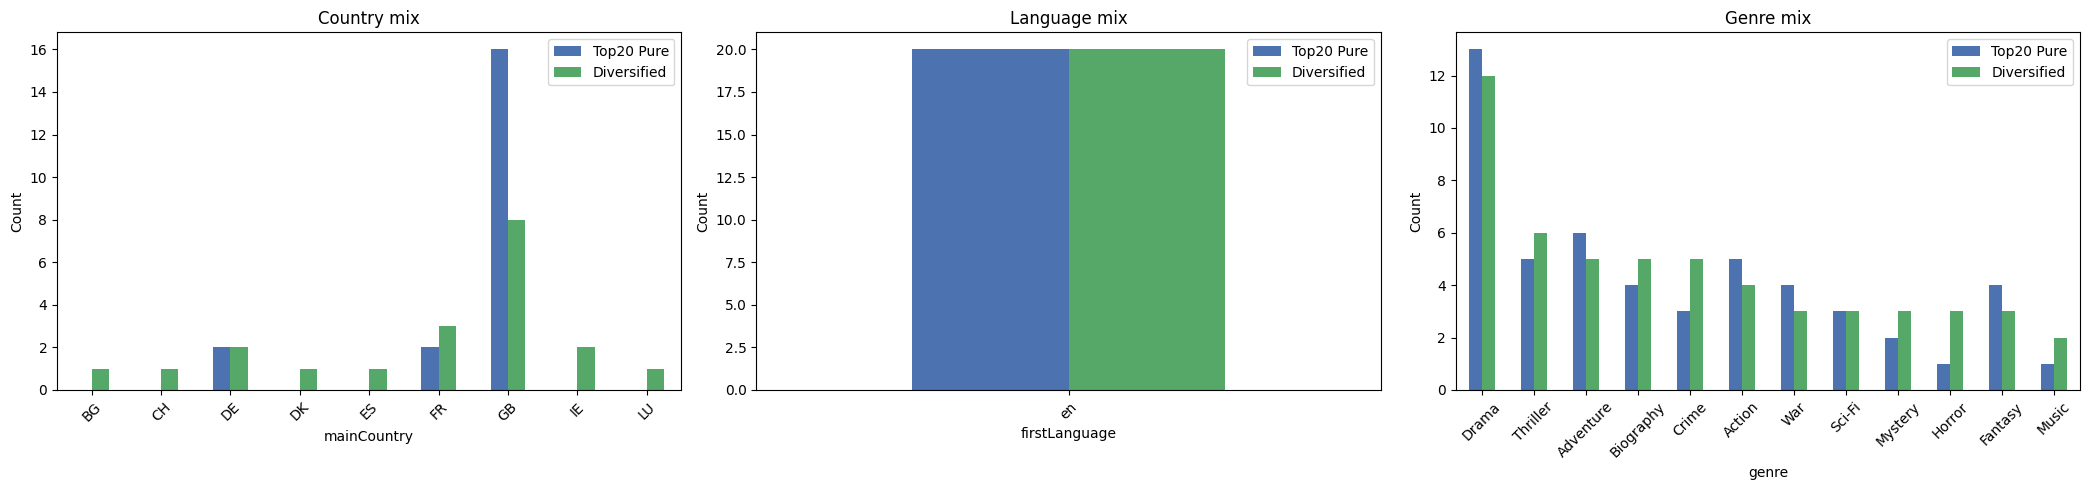

In [19]:
def top_counts(series, n=10):
    return series.fillna("Unknown").astype(str).value_counts().head(n)

country_plot = pd.DataFrame(
    {
        "Top20 Pure": top_counts(top20_pure["mainCountry"], 10),
        "Diversified": top_counts(portfolio_df["mainCountry"], 10),
    }
).fillna(0)

language_plot = pd.DataFrame(
    {
        "Top20 Pure": top_counts(top20_pure["firstLanguage"], 10),
        "Diversified": top_counts(portfolio_df["firstLanguage"], 10),
    }
).fillna(0)

pure_genres = top20_pure["genres"].fillna("").astype(str).str.split(",").explode().str.strip()
pure_genres = pure_genres[pure_genres != ""]

diverse_genres = portfolio_df["genres"].fillna("").astype(str).str.split(",").explode().str.strip()
diverse_genres = diverse_genres[diverse_genres != ""]

genre_plot = pd.DataFrame(
    {
        "Top20 Pure": pure_genres.value_counts(),
        "Diversified": diverse_genres.value_counts(),
    }
).fillna(0)

genre_plot = genre_plot.sort_values("Diversified", ascending=False).head(12)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

country_plot.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Country mix")
axes[0].set_xlabel("mainCountry")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

language_plot.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#55A868"])
axes[1].set_title("Language mix")
axes[1].set_xlabel("firstLanguage")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

genre_plot.plot(kind="bar", ax=axes[2], color=["#4C72B0", "#55A868"])
axes[2].set_title("Genre mix")
axes[2].set_xlabel("genre")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Assumptions and limitations (state clearly)

- `imdbRating` is a proxy for perceived quality, not platform-specific satisfaction.
- `numberOfVotes` is a proxy for public attention, not direct demand on this platform.
- Analysis is intentionally constrained to English-only (`firstLanguage == "en"`) for cleaner positioning.
- No revenue, licensing cost, watch-time, or user-level behavior is used.
- This notebook provides acquisition prioritization support, not ROI prediction.
- Portfolio weights and caps are managerial assumptions; run sensitivity checks before final decisions.

## Practical stakeholder output
Use these as final deliverables:
1. Top-20 pure score ranking (English-only)
2. Diversified top-20 portfolio (English-only)
3. Side-by-side coverage metrics and composition charts
4. Fight Club diagnostics (why it ranks highly)
5. Weight sensitivity chart for robustness discussion
